In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [119]:

df = pd.read_excel('../Data/imdb_anime.xlsx')

# Exploración Inicial

---

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45717 entries, 0 to 45716
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            45717 non-null  object
 1   Genre            45717 non-null  object
 2   User Rating      25009 non-null  object
 3   Number of Votes  25009 non-null  object
 4   Runtime          32549 non-null  object
 5   Year             45591 non-null  object
 6   Summary          23547 non-null  object
 7   Stars            13676 non-null  object
 8   Certificate      28694 non-null  object
 9   Metascore        341 non-null    object
 10  Gross            25009 non-null  object
 11  Episode          45717 non-null  object
 12  Episode Title    34910 non-null  object
dtypes: object(13)
memory usage: 4.5+ MB


- Todas las columnas son del tipo **objeto**.
- El dataframe posee **45717 filas** y **13 columnas**.
- Las columnas parecen tener sus nombres todo en title y no se ven problemas en estas.
- A primera vista se ven varias columnas con nulos y en particular la columna `Metascore` se encuentra llena de nulos.
- Hay columnas como `runtime`, `year`, `stars` que probablemente deben ser numéricas pero están como objetos


### INSIGHT:

Lo primero debe ser ver el problema de nulos, revisar duplicados y  los tipos de datos ya que no podemos hacer un `.describe()` como para poder saber más información de los datos

### **Duplicados**

In [121]:
print(f'El número de datos duplicados es de {df.duplicated().sum()}')

El número de datos duplicados es de 874


In [122]:
df.drop_duplicates(inplace=True)

### **NULOS**

<Axes: title={'center': 'total de nulos'}>

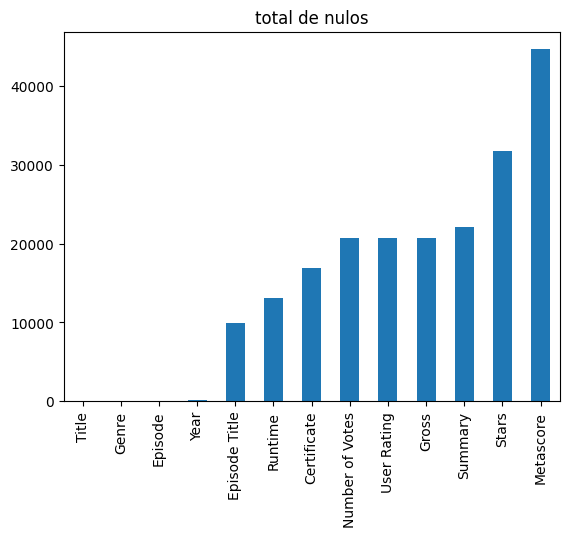

In [123]:
df.isnull().sum().sort_values().plot(kind='bar', title='total de nulos')

## **Revisando el contenido de las columnas de forma rápida**

In [149]:

for col in df.columns:
    print(df[col].unique())
    print('\n')

['One Piece' 'Teenage Mutant Ninja Turtles: Mutant Mayhem'
 'The Super Mario Bros. Movie' ...
 'Kochira Katsushika-ku Kameari Koen Mae Hashutsujo'
 'Izumo: Flash of a Brave Sword' 'Future GPX Cyber Formula']


['Animation, Action, Adventure' 'Animation, Adventure, Comedy'
 'Animation, Drama, Family' 'Animation, Action, Drama'
 'Animation, Adventure, Drama' 'Animation, Action, Comedy'
 'Animation, Adventure, Family' 'Animation, Crime, Drama'
 'Animation, Drama, Fantasy' 'Animation, Comedy, Family'
 'Animation, Comedy, Drama' 'Animation, Family, Fantasy'
 'Animation, Drama, War' 'Animation, Adventure, Mystery'
 'Animation, Action, Fantasy' 'Animation, Action, Crime'
 'Animation, Drama' 'Animation, Biography, Drama'
 'Animation, Comedy, Romance' 'Animation, Adventure, Sci-Fi'
 'Animation, Sport, Thriller' 'Animation, Drama, Thriller'
 'Animation, Drama, Horror' 'Animation, Action, Sport' 'Animation, Comedy'
 'Animation, Action, Sci-Fi' 'Animation, Drama, Romance'
 'Animation, Adventure, F

`title` = str |
`Genre` = str [categorías] |
`summary` = str |
`Stars` = str |
`Certificate` = str |
`Episode Title`= str


`User rating` = float |
`Number of votes` = Int |
`runtime` = Int |
`Metascore` = Int |
`Gross` = Int 


`Year` = DATETIME [RANGO]


### **COLUMNAS NUMÉRICAS**

In [130]:
df['Runtime']

0        24 min
1        99 min
2        92 min
3        24 min
4        24 min
          ...  
45712    24 min
45713    24 min
45714       NaN
45715    24 min
45716    24 min
Name: Runtime, Length: 44843, dtype: object

In [136]:
pd.to_numeric(df['User Rating'].replace('User Rating', ''), errors='raise')

0        8.9
1        7.4
2        7.1
3        9.1
4        8.5
        ... 
45712    7.3
45713    7.9
45714    9.4
45715    NaN
45716    6.0
Name: User Rating, Length: 44843, dtype: float64

In [138]:
pd.to_numeric(df['Number of Votes'].replace('Number of Votes', ''), errors='raise')

0        187689.0
1         28895.0
2        189108.0
3        434457.0
4         82909.0
           ...   
45712      3432.0
45713      3309.0
45714      2743.0
45715         NaN
45716         6.0
Name: Number of Votes, Length: 44843, dtype: float64

In [144]:
pd.to_numeric(df['Runtime'].replace({' min':'', 'Runtime':'', ',':'.'}, regex=True), errors='raise')


0        24.0
1        99.0
2        92.0
3        24.0
4        24.0
         ... 
45712    24.0
45713    24.0
45714     NaN
45715    24.0
45716    24.0
Name: Runtime, Length: 44843, dtype: float64

In [146]:
pd.to_numeric(df['Metascore'].replace({'Metascore':''}, regex=True), errors='raise')


0         NaN
1        74.0
2        46.0
3         NaN
4         NaN
         ... 
45712     NaN
45713     NaN
45714     NaN
45715     NaN
45716     NaN
Name: Metascore, Length: 44843, dtype: float64

In [148]:
pd.to_numeric(df['Gross'].replace({'Gross':''}, regex=True), errors='raise')



0        187689.0
1         28895.0
2        189108.0
3        434457.0
4         82909.0
           ...   
45712      3432.0
45713      3309.0
45714      2743.0
45715         NaN
45716         6.0
Name: Gross, Length: 44843, dtype: float64